In [1]:
import csv
import random
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import pandas as pd

from time import sleep
from collections import deque
from itertools import count
from typing import Any, Dict, List, Optional, Tuple, Set

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from importnb import Notebook
with Notebook():
    from LabLatencyModel import LatencyModel, MultiDULatencyModel
    from LabCacheEngine import CacheEngineEnv
    from LabUserRequest import UserRequestEvents
    from LabEnvWrapper import EnvWrapper

import os
import sys

sources_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
if sources_path not in sys.path:
    sys.path.append(sources_path)

import Common.config as config
import Common.datatypes as datatypes
import Common.utils as utils

import importlib

importlib.reload(config)
importlib.reload(datatypes)
importlib.reload(utils)

<module 'Common.utils' from '/home/eduardo/Workspace/CacheVideoPredict360/Sources/Common/utils.py'>

In [2]:
CacheKey = datatypes.CacheKey  # (vid, layer, tile, gop)

cfg = config.Config()

cfg.filename = f"lru_c{int(cfg.cache_capacity/1e9)}GB_ar{int(cfg.arrival_rate)}_z{cfg.zipf_alpha}.csv"
cfg.n_episodes = 10

In [3]:
class LruPolicy(datatypes.CachePolicy):

    def __init__(self, max_videos: int = 50, max_tiles: int = 4) -> None:
        self.video_capacity = max_videos  # None or <=0 means unlimited videos
        self.tiles_capacity = max_tiles  # None or <=0 means unlimited tiles per video
        
        # key = (vid, layer, _, _) -> value = (payload, size)
        self.video_cache: Dict[datatypes.CacheKey, Tuple[Any, int]] = {}

        # Video LRU: oldest video (by any access to its tiles) at index 0
        self.video_access_order: List[int] = []
        
        self.video_tiles: Dict[int, List[int]] = {} # vid -> list of enhancement tiles in cache 
        
    # ----------------------- Internal helpers -----------------------

    def _touch_video(self, key: datatypes.CacheKey) -> None:
        """Mark a key as most recently used."""
        vid, _, _, _ = key
        if vid in self.video_access_order:
            self.video_access_order.remove(vid)
        self.video_access_order.append(vid)

    def _touch_tile(self, vid: int, tile: int) -> None:
        """Mark a tile as most recently used within its video."""
        if tile in self.video_tiles[vid]:
            self.video_tiles[vid].remove(tile)
        self.video_tiles[vid].append(tile)
        
    def _put_base_layer(
        self, 
        key: datatypes.CacheKey, 
        value: Any, 
        size: int
    ) -> None:
        self.video_cache[key] = (value, size)
        self._touch_video(key)
        
    def _put_enhancement_tile(
        self, 
        key: datatypes.CacheKey,
        vid: int,
        tile: int
    ) -> List[datatypes.CacheKey]:
        if vid not in self.video_tiles:
            self.video_tiles[vid] = []
            
        self._touch_tile(vid, tile)
        
    # ----------------------- Public API -----------------------

    def get(self, key: datatypes.CacheKey) -> Optional[Any]:
        if key not in self.video_cache:
            return None
        self._touch_video(key)
        return self.video_cache[key][0]

    def put(
        self, 
        key: datatypes.CacheKey, 
        value: Any, 
        size: int
    ) -> List[datatypes.CacheKey]:
        
        evicted: List[datatypes.CacheKey] = []
        vid, layer, tile, _ = key

        if layer == 0:
            self._put_base_layer(key, value, size)
            
            if len(self.video_access_order) > self.video_capacity:
                evict_vid = self.video_access_order.pop(0)
                self.video_tiles.pop(evict_vid)
                
                del self.video_cache[(evict_vid, 0, None, None)]
                
                return [(evict_vid, 0, None, None)]
        elif layer == 1:
            self._put_enhancement_tile(key, vid, tile)
            
            if len(self.video_tiles[vid]) > self.tiles_capacity:
                evict_tile = self.video_tiles[vid].pop(0)
                
                return [(vid, 1, evict_tile, None)]
        else:
            raise ValueError(f"Unsupported layer: {layer}")

        return evicted
        
    def contains(self, key: datatypes.CacheKey) -> bool:
        return key in self.video_cache

    def remove(self, key: datatypes.CacheKey) -> bool:
        raise NotImplementedError("LRU policy does not support manual removal of individual keys.")

    def clear(self) -> None:
        self.video_cache.clear()
        self.video_tiles.clear()
        self.video_access_order.clear()

    def get_capacity(self) -> int:
        return sum(size for _, size in self.video_cache.values())

    def stats(self) -> Dict[str, Any]:
        return {
            "size": self.cur_size,
            "max_size": self.max_size,
            "num_items": len(self.video_cache),
            "num_videos": len(self.video_idx),
            "max_videos": self.max_videos if self.max_videos is not None else float("inf"),
            "utilization": self.cur_size / self.max_size if self.max_size > 0 else 0.0,
        }

    def keys(self):
        return self.video_cache.keys()

In [4]:
class LruPolicyv2(datatypes.CachePolicy):
    """
    Anytime we need to evict, we evict the least recently used item(s) based on the hierarchy: video → GOP → tile. Eviction order:
        1. Evict entire videos (all GOPs and tiles) if video count exceeds max_videos.
        2. If the video itself is still present, evict entire GOPs (base + all enhancements) if GOP count for that video exceeds max_gops_per_video.
        3. If the GOP itself is still present, evict enhancement tiles (layer=1) in LRU order if tile count for that (vid, gop) exceeds max_tiles_per_gop. Base layer (layer=0) is never evicted in this step.
    """
    def __init__(self, max_videos: int = 50, max_gops_per_video: int = 30, max_tiles_per_gop: int = 4) -> None:
        self.max_videos = max_videos
        self.max_gops_per_video = max_gops_per_video
        self.max_tiles_per_gop = max_tiles_per_gop
        
        # Main storage: key -> (value, size)
        self._store: Dict[CacheKey, Tuple[Any, int]] = {}
        
        # ---------- LRU structures ----------
        # Video LRU (oldest video at index 0)
        self._video_lru: List[int] = []

        # GOP LRU per video: vid -> [gop_id oldest..newest]
        self._gop_lru: Dict[int, List[int]] = {}

        # Tile LRU per (vid, gop): vid -> { gop -> [tile oldest..newest] }
        self._tile_lru: Dict[int, Dict[int, List[int]]] = {}

        # ---------- Indexes for fast deletion ----------
        # Keys per video: vid -> set(keys)
        self._keys_by_video: Dict[int, Set[CacheKey]] = {}

        # Base key index: (vid, gop) -> base_key (or None if absent)
        self._base_index: Dict[Tuple[int, int], Optional[CacheKey]] = {}

        # Enhancement index: vid -> gop -> tile -> key
        self._enh_index: Dict[int, Dict[int, Dict[int, CacheKey]]] = {}

    # --------------------------------------------------------------------- #
    # Helpers: LRU management
    # --------------------------------------------------------------------- #

    def _touch_video(self, vid: int) -> None:
        """Move a video to MRU position."""
        if vid in self._video_lru:
            self._video_lru.remove(vid)
        self._video_lru.append(vid)

    def _touch_gop(self, vid: int, gop: int) -> None:
        """Move a GOP within a video to MRU position."""
        lst = self._gop_lru.setdefault(vid, [])
        if gop in lst:
            lst.remove(gop)
        lst.append(gop)

    def _touch_tile(self, vid: int, gop: int, tile: int) -> None:
        """Move a tile within (vid, gop) to MRU position."""
        per_vid = self._tile_lru.setdefault(vid, {})
        lst = per_vid.setdefault(gop, [])
        if tile in lst:
            lst.remove(tile)
        lst.append(tile)

    # --------------------------------------------------------------------- #
    # Helpers: Index maintenance
    # --------------------------------------------------------------------- #

    def _index_add(self, key: CacheKey, size: int) -> None:
        vid, layer, tile, gop = key
        self._store[key] = (self._store.get(key, (None, 0))[0], size) if key in self._store else (None, size)
        # ensure key presence in store has been set by caller before indexing
        self._keys_by_video.setdefault(vid, set()).add(key)

        if layer == 0:
            self._base_index[(vid, gop)] = key
        else:
            self._enh_index.setdefault(vid, {}).setdefault(gop, {})[tile] = key

    def _index_remove(self, key: CacheKey) -> None:
        if key not in self._store:
            return
        vid, layer, tile, gop = key

        # remove from store
        del self._store[key]

        # remove from per-video set
        vset = self._keys_by_video.get(vid)
        if vset:
            vset.discard(key)
            if not vset:
                # if no keys left for this video, drop video LRU entry as well
                self._keys_by_video.pop(vid, None)
                if vid in self._video_lru:
                    self._video_lru.remove(vid)
                self._gop_lru.pop(vid, None)
                self._tile_lru.pop(vid, None)
                self._enh_index.pop(vid, None)

        # update base/enh indexes
        if layer == 0:
            if self._base_index.get((vid, gop)) == key:
                self._base_index.pop((vid, gop), None)
            # also drop GOP LRU entry if GOP becomes empty later
        else:
            per_vid = self._enh_index.get(vid, {})
            per_gop = per_vid.get(gop, {})
            if per_gop.get(tile) == key:
                per_gop.pop(tile, None)
            if not per_gop and gop in per_vid:
                per_vid.pop(gop, None)

        # clean LRU nodes for GOP/tile if needed
        if vid in self._gop_lru and gop in self._gop_lru[vid]:
            # keep GOP in LRU only if ANY key remains for that GOP
            if not self._has_any_key_for_gop(vid, gop):
                self._gop_lru[vid].remove(gop)

        if vid in self._tile_lru and gop in self._tile_lru[vid]:
            tl = self._tile_lru[vid][gop]
            if tile in tl:
                tl.remove(tile)
            if not tl:
                self._tile_lru[vid].pop(gop, None)

    def _has_any_key_for_gop(self, vid: int, gop: int) -> bool:
        """Return True if base or any enhancement exists for (vid, gop)."""
        if self._base_index.get((vid, gop)) is not None:
            return True
        return bool(self._enh_index.get(vid, {}).get(gop, {}))

    # --------------------------------------------------------------------- #
    # Helpers: Eviction primitives
    # --------------------------------------------------------------------- #

    def _evict_entire_video(self, evict_vid: int, out: List[CacheKey]) -> None:
        """Evict all keys for a given video (and clean indexes)."""
        keys = list(self._keys_by_video.get(evict_vid, set()))
        for k in keys:
            self._index_remove(k)
            out.append(k)

    def _evict_oldest_video_if_needed(self, out: List[CacheKey]) -> None:
        if self.max_videos is not None and self.max_videos > 0:
            while len(self._keys_by_video) > self.max_videos:
                if not self._video_lru:
                    break
                evict_vid = self._video_lru[0]
                # If the oldest video was just touched but isn't first, ensure we pick
                # the true oldest:
                # (List is maintained; this is just a safety check.)
                self._evict_entire_video(evict_vid, out)

    def _evict_oldest_gop_if_needed(self, vid: int, out: List[CacheKey]) -> None:
        if self.max_gops_per_video is not None and self.max_gops_per_video > 0:
            glist = self._gop_lru.setdefault(vid, [])
            # Count GOPs by existence in either base/enh indexes
            def _count_gops(v: int) -> int:
                present = set()
                # From base index
                for (v2, g) in self._base_index.keys():
                    if v2 == v:
                        present.add(g)
                # From enhancement index
                for g in self._enh_index.get(v, {}).keys():
                    present.add(g)
                return len(present)

            while _count_gops(vid) > self.max_gops_per_video and glist:
                oldest_gop = glist[0]
                self._evict_gop(vid, oldest_gop, out)

    def _evict_gop(self, vid: int, gop: int, out: List[CacheKey]) -> None:
        """Evict base + all enhancements of (vid, gop)."""
        # Base
        bkey = self._base_index.pop((vid, gop), None)
        if bkey is not None and bkey in self._store:
            self._index_remove(bkey)
            out.append(bkey)

        # Enhancements
        enh_map = self._enh_index.get(vid, {}).pop(gop, {})
        for tkey in list(enh_map.values()):
            if tkey in self._store:
                self._index_remove(tkey)
                out.append(tkey)

        # Clean GOP/tile LRU structures
        if vid in self._gop_lru and gop in self._gop_lru[vid]:
            self._gop_lru[vid].remove(gop)
        if vid in self._tile_lru:
            self._tile_lru[vid].pop(gop, None)

    def _evict_oldest_tile_if_needed(self, vid: int, gop: int, out: List[CacheKey]) -> None:
        if self.max_tiles_per_gop is not None and self.max_tiles_per_gop > 0:
            tile_list = self._tile_lru.setdefault(vid, {}).setdefault(gop, [])
            while len(tile_list) > self.max_tiles_per_gop:
                oldest_tile = tile_list[0]
                # remove enhancement only
                tkey = self._enh_index.get(vid, {}).get(gop, {}).get(oldest_tile)
                if tkey is not None:
                    self._index_remove(tkey)
                    out.append(tkey)
                else:
                    # stale tile in LRU (shouldn't happen, but guard anyway)
                    tile_list.pop(0)

    # --------------------------------------------------------------------- #
    # Public API
    # --------------------------------------------------------------------- #

    def get(self, key: CacheKey) -> Optional[Any]:
        if key not in self._store:
            return None
        vid, layer, tile, gop = key
        # touch LRU structures
        self._touch_video(vid)
        self._touch_gop(vid, gop)
        if layer > 0:
            self._touch_tile(vid, gop, tile)
        return self._store[key][0]

    def put(self, key: CacheKey, value: Any, size: int) -> List[CacheKey]:
        """
        Insert or update a key, possibly evicting entries to satisfy the capacities.
        Returns the list of evicted keys.
        """
        evicted: List[CacheKey] = []
        vid, layer, tile, gop = key

        # If key already exists, just update value/recency (no eviction needed for same item).
        if key in self._store:
            self._store[key] = (value, size)

            if layer == 0:
                self._touch_video(vid)

            self._touch_gop(vid, gop)

            if layer == 1:
                self._touch_tile(vid, gop, tile)

            return evicted

        # Insert in main store first (value, size); index after LRU touches
        self._store[key] = (value, size)

        # Touch LRU levels
        if layer == 0:
            self._touch_video(vid)
            
        self._touch_gop(vid, gop)

        # Update indexes
        self._keys_by_video.setdefault(vid, set()).add(key)
        if layer == 0:
            self._base_index[(vid, gop)] = key
        else:
            self._enh_index.setdefault(vid, {}).setdefault(gop, {})[tile] = key
            self._touch_tile(vid, gop, tile)

        # Capacity enforcement

        # (1) Video capacity → evict entire videos (video-LRU)
        self._evict_oldest_video_if_needed(evicted)

        # If the video itself was evicted in step (1), nothing else to do
        if vid not in self._keys_by_video:
            return evicted

        # (2) GOP capacity per video → evict oldest GOP(s) for this video (base + enh)
        self._evict_oldest_gop_if_needed(vid, evicted)

        # If this GOP was evicted as a side effect, bail out
        if not self._has_any_key_for_gop(vid, gop):
            return evicted

        # (3) Tile capacity per (vid, gop) → evict oldest enhancement tiles in SAME (vid, gop)
        if layer == 1:
            self._evict_oldest_tile_if_needed(vid, gop, evicted)

        return evicted

    def contains(self, key: CacheKey) -> bool:
        return key in self._store

    def remove(self, key: CacheKey) -> bool:
        """Explicit removal. If removing a base, it also cascades to remove enhancements of that (vid, gop)."""
        if key not in self._store:
            return False
        vid, layer, tile, gop = key
        evicted: List[CacheKey] = []
        if layer == 0:
            self._evict_gop(vid, gop, evicted)  # base + all enh in that GOP
            return True
        else:
            self._index_remove(key)
            return True

    def clear(self) -> None:
        self._store.clear()
        self._video_lru.clear()
        self._gop_lru.clear()
        self._tile_lru.clear()
        self._keys_by_video.clear()
        self._base_index.clear()
        self._enh_index.clear()

    def get_capacity(self) -> int:
        """Aggregate 'size' across stored keys. (Count-based policy still supported.)"""
        return sum(sz for (_, sz) in self._store.values())

    def stats(self) -> Dict[str, Any]:
        """Diagnostics for debugging or analytics."""
        num_videos = len(self._keys_by_video)
        num_keys = len(self._store)

        # count gops per video from indexes
        gops_per_video = {
            vid: len(
                set(
                    [g for (v2, g) in self._base_index.keys() if v2 == vid]
                ).union(
                    set(self._enh_index.get(vid, {}).keys())
                )
            )
            for vid in self._keys_by_video.keys()
        }

        return {
            "num_items": num_keys,
            "num_videos": num_videos,
            "max_videos": self.max_videos,
            "max_gops_per_video": self.max_gops_per_video,
            "max_tiles_per_gop": self.max_tiles_per_gop,
            "gops_per_video": gops_per_video,
            "video_lru": list(self._video_lru),
        }

    def keys(self):
        return self._store.keys()


In [ ]:
if __name__ == "__main__":

    du_caches = []
    
    policy=LruPolicy(
        max_videos=cfg.cache_size,
        max_tiles=cfg.viewport
    )
    
    mec_cache = CacheEngineEnv(
        n_users=cfg.n_users,
        n_videos=cfg.n_videos,
        n_layers=cfg.n_layers,
        n_tiles=cfg.n_tiles,
        n_gops=cfg.n_gops,
        cache_capacity=cfg.cache_capacity,
        policy=policy
    )

    # Initialize User Environment
    users_env = UserRequestEvents(
        n_nodes=cfg.n_nodes,
        n_users=cfg.n_users,
        n_videos=cfg.n_videos,
        n_gops=cfg.n_gops,
        n_layers=cfg.n_layers,
        n_tiles=cfg.n_tiles,
        n=cfg.n,
        users_viewport_tiles=None,
        requested_videos=None,
        users_arrivals=None,
        arrival_rate=cfg.arrival_rate,
        zipf_alpha=cfg.zipf_alpha,
    )

    # Create latency model (replace numbers with your real config)
    P = cfg.n_nodes; max_U = cfg.n_users
    lat_model = MultiDULatencyModel(
        P=P, 
        max_U=max_U,
        R_M_D=80e6,   # 640 Mbps -> 80e6 B/s
        R_C_M=125e6, # 1 Gbps -> 125e6 B/s
        mu=2e7, 
        eta=2e5,
        B_pu_matrix=np.full((P, max_U), 40e6, dtype=float),    # 320 Mbps -> 40e6 B/s
        gamma_pu_matrix=np.full((P, max_U), 5.0, dtype=float), # SNRs
        rhoT_p=[0.2], 
        lambda_p=[0.05],
        du_fixed_delay=0.001,    # 1 ms
        mec_fixed_delay=0.005,   # 5 ms
        cloud_fixed_delay=0.1   # 100 ms
    )

    def prefetch_fn(cache, action):
        return cache.lru_live_prefetching(action)
    
    def reward_fn(env, psnr):
        return env.compute_reward(psnr)

    env = EnvWrapper(
        n=cfg.n,
        m=cfg.m,
        n_layers=cfg.n_layers,
        users_env=users_env, 
        du_caches=du_caches,
        mec_cache=mec_cache,
        latency_model=lat_model,
        theta=cfg.theta,
        lam=cfg.lam,
        max_steps=cfg.max_steps,
        prefetch_fn=prefetch_fn,
        reward_fn=reward_fn
    )

    print(
        f"Experiment ===================\n"
        f"Total users: {cfg.n_users}\n"
        f"Cache capacity: {int(cfg.cache_capacity)}\n"
        f"Max videos: {cfg.cache_size}\n"
        f"Video matrix: {cfg.n_videos}x{cfg.n_layers}x{cfg.n*cfg.m}\n"
        f"==============================\n"
    )

    results = []
    scores = []
    active_users_log = []  # Track active users per step

    for ep in range(cfg.n_episodes):

        obs, info = env.reset()

        cache_hits = 0
        cache_misses = 0
        soft_hits = 0.0
        total_reward = 0.0
        avg_psnr = []

        for step in count():

            reqs = info['users_requests']
            
            actions = []
            action_taken = False

            for req in reqs:
                u = req["u"]
                v = req["video"]
                g = req["gop"]
                tiles = req["tiles"]
                viewport = req["viewport"]
                base_req_init = req["base_req_init"]

                has_base_layer = any(
                    t.get("events", {}).get("alpha_M_u") == 1 for t in tiles
                )

                if not has_base_layer:
                    actions.append({
                        'user': u,
                        'gop': g,
                        'video': v,
                        'tiles': viewport,
                        'base_req_init': base_req_init
                    })
                elif has_base_layer:
                    actions.append({
                        'user': u,
                        'gop': g,
                        'video': v,
                        'tiles': viewport,
                        'base_req_init': False
                    })

            # --- STEP ENV ---
            obs, reward, done, info = env.step(actions)

            if done:
                break

            reward_delta, hits_delta, misses_delta, _ = utils.update_metrics(info, reward)
            total_reward += reward_delta
            cache_hits += hits_delta
            cache_misses += misses_delta

        utils.save_training_results(
            path_=cfg.path_results,
            filename=cfg.filename,
            ep=ep,
            total_reward=total_reward,
            cache_hits=cache_hits,
            cache_misses=cache_misses,
            soft_hits=soft_hits,
            agent=None
        )

        total_requests = sum(reqs for reqs in env.total_gop_requests_per_user.values())

        print(f"--- Episode {ep} completed. Total Reward: {total_reward:.2f}, Cache Hits: {cache_hits}, Cache Misses: {cache_misses}, Total Requests: {total_requests} ---")

Experiment ===================
Total users: 500
Cache capacity: 10500000000
Max videos: 50
Video matrix: 500x2x12

--- Episode 0 completed. Total Reward: 11343.30, Cache Hits: 252562, Cache Misses: 171630, Total Requests: 0 ---
--- Episode 1 completed. Total Reward: 11515.30, Cache Hits: 271628, Cache Misses: 154596, Total Requests: 0 ---
--- Episode 2 completed. Total Reward: 14091.79, Cache Hits: 265133, Cache Misses: 146307, Total Requests: 0 ---


Loading data from: /home/eduardo/Workspace/CacheVideoPredict360/Results/lru_c10GB_ar20_z0.8.csv


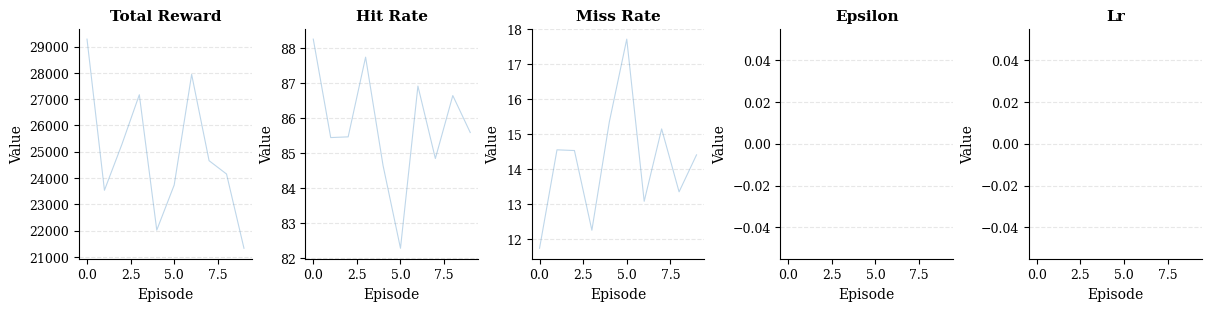

In [ ]:
# ----------------------------------------------------------------      
# 1. Publication Style Configuration
# ----------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.8,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True
})

# Professional color for line plots
PRIMARY_COLOR = "#2b7bba"

# ----------------------------------------------------------------
# 2. Data Loading & Smoothing
# ----------------------------------------------------------------
path = cfg.path_results + "/" + cfg.filename

print(f"Loading data from: {path}")

df = pd.read_csv(path)

total = (df["cache_hits"] + df["cache_misses"]).replace(0, np.nan)
df["hit_rate"] = (df["cache_hits"] / total) * 100
df["miss_rate"] = (df["cache_misses"] / total) * 100

# Metrics to plot
metrics = ["total_reward", "hit_rate", "miss_rate", "epsilon", "lr"]
window_size = 10  # Adjust smoothing window as needed

# ----------------------------------------------------------------
# 3. Plotting logic
# ----------------------------------------------------------------
# Adjusted figsize for a 4-column row (standard for full-width paper figures)
fig, axes = plt.subplots(1, len(metrics), figsize=(12, 3), sharex=True)

for ax, col in zip(axes, metrics):
    # Plot raw data with transparency (alpha)
    ax.plot(df["episode"], df[col], color=PRIMARY_COLOR, alpha=0.3, linewidth=0.8, label='Raw')
    
    # Plot moving average for clearer trend (except for epsilon which is usually linear)
    if col != "epsilon":
        smoothed = df[col].rolling(window=window_size).mean()
        ax.plot(df["episode"], smoothed, color=PRIMARY_COLOR, linewidth=1.5, label='Trend')
    else:
        # Just a solid line for Epsilon
        ax.plot(df["episode"], df[col], color=PRIMARY_COLOR, linewidth=1.5)

    # Stylistic cleanup
    ax.set_title(col.replace("_", " ").title(), fontweight="bold")
    ax.set_xlabel("Episode")
    
    # Remove redundant Y-labels to save space, or keep for clarity
    ax.set_ylabel("Value") 
    
    series = df[col].dropna()
    if not series.empty:
        ymin = series.min()
        ymax = series.max()
        pad = (ymax - ymin) * 0.05 if ymax != ymin else 1.0
        ax.set_ylim(ymin - pad, ymax + pad)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Tufte-style: remove top/right spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

# Optional: Add a single legend to the first plot if needed
# axes[0].legend(frameon=False)

plt.show()
fig.savefig("drl_caching_metrics.png", dpi=300)

C:\Users\es25591\AppData\Local\Temp\ipykernel_30704\3657158268.py:17: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[0].set_ylim(bottom=0)  # <--- Forces y-axis to start at 0
C:\Users\es25591\AppData\Local\Temp\ipykernel_30704\3657158268.py:27: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[1].set_ylim(bottom=0)  # <--- Forces y-axis to start at 0
C:\Users\es25591\AppData\Local\Temp\ipykernel_30704\3657158268.py:37: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[2].set_ylim(bottom=0)
C:\Users\es25591\AppData\Local\Temp\ipykernel_30704\3657158268.py:41: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


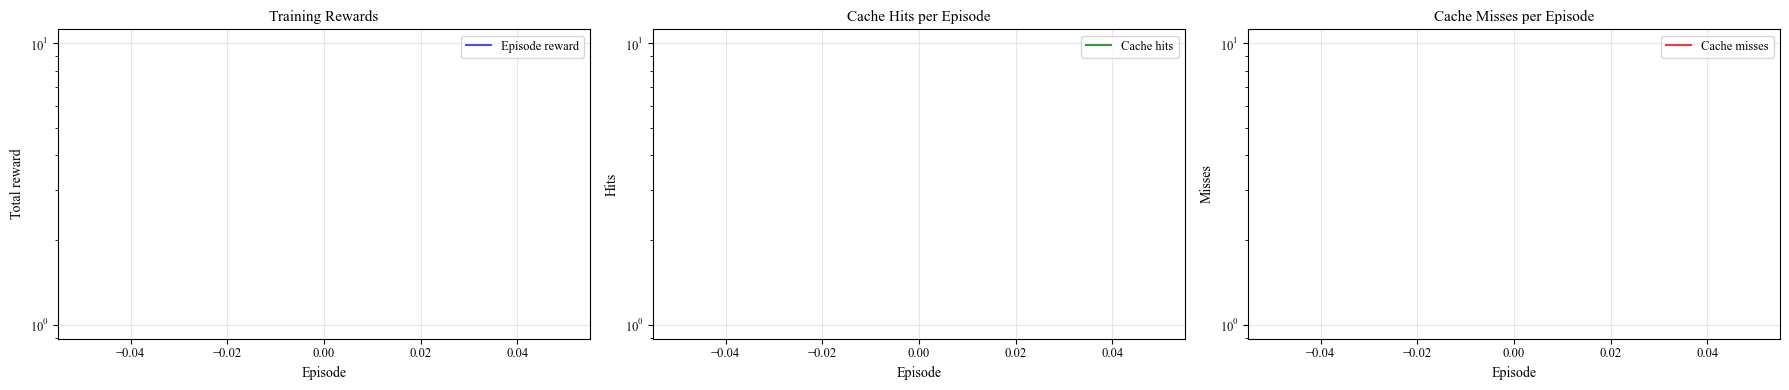

In [ ]:
episodes = range(1, len(scores) + 1)
cache_hits_series = [r["cache_hits"] for r in results]
cache_misses_series = [r["cache_misses"] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)

# 1. Rewards with moving average
axes[0].plot(episodes, scores, label="Episode reward", alpha=0.7, color="blue")
w = max(1, min(20, len(scores) // 10))
if w > 1:
    ma = [sum(scores[i - w:i]) / w for i in range(w, len(scores) + 1)]
    axes[0].plot(range(w, len(scores) + 1), ma, label=f"Moving avg (w={w})", color="orange")
axes[0].set_yscale('log') 
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total reward")
axes[0].set_title("Training Rewards")
axes[0].set_ylim(bottom=0)  # <--- Forces y-axis to start at 0
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# 2. Cache hits
axes[1].plot(episodes, cache_hits_series, label="Cache hits", color="green", alpha=0.8)
axes[1].set_yscale('log') 
axes[1].set_title("Cache Hits per Episode")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Hits")
axes[1].set_ylim(bottom=0)  # <--- Forces y-axis to start at 0
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# 3. Cache misses
axes[2].plot(episodes, cache_misses_series, label="Cache misses", color="red", alpha=0.8)
axes[2].set_yscale('log')
axes[2].set_title("Cache Misses per Episode")
axes[2].set_xlabel("Episode")
axes[2].set_ylabel("Misses")
axes[2].set_ylim(bottom=0)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

C:\Users\es25591\AppData\Local\Temp\ipykernel_30704\2542068820.py:38: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


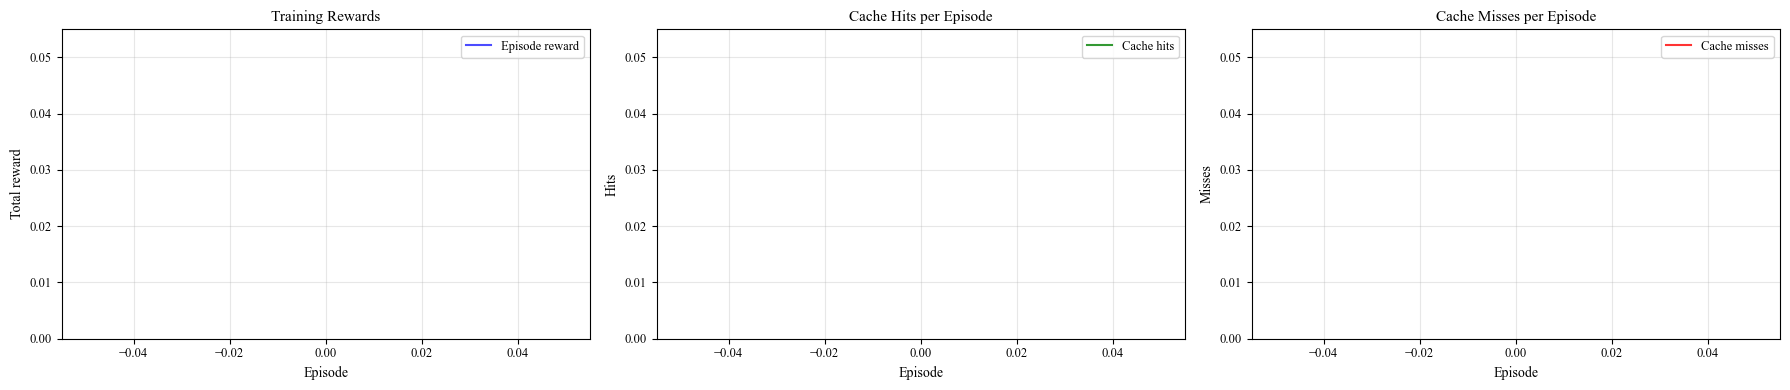

In [ ]:
episodes = range(1, len(scores) + 1)
cache_hits_series = [r["cache_hits"] for r in results]
cache_misses_series = [r["cache_misses"] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)

# Rewards with moving average
axes[0].plot(episodes, scores, label="Episode reward", alpha=0.7, color="blue")
w = max(1, min(20, len(scores) // 10))
if w > 1:
    ma = [sum(scores[i - w:i]) / w for i in range(w, len(scores) + 1)]
    axes[0].plot(range(w, len(scores) + 1), ma, label=f"Moving avg (w={w})", color="orange")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total reward")
axes[0].set_title("Training Rewards")
axes[0].set_ylim(bottom=0)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Cache hits
axes[1].plot(episodes, cache_hits_series, label="Cache hits", color="green", alpha=0.8)
axes[1].set_title("Cache Hits per Episode")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Hits")
axes[1].set_ylim(bottom=0)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Cache misses
axes[2].plot(episodes, cache_misses_series, label="Cache misses", color="red", alpha=0.8)
axes[2].set_title("Cache Misses per Episode")
axes[2].set_xlabel("Episode")
axes[2].set_ylabel("Misses")
axes[2].set_ylim(bottom=0)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
from typing import List
import os

def read_results(csv_path: str):
    episodes: List[int] = []
    enhanced_hits: List[float] = []
    enhanced_misses: List[float] = []
    base_hits: List[float] = []
    base_misses: List[float] = []

    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV file not found: {csv_path}")

    with open(csv_path, "r", newline="") as f:
        reader = csv.DictReader(f)
        required_cols = [
            "episode",
            "enhanced_layer_cache_hits",
            "enhanced_layer_cache_misses",
            "base_layer_cache_hits",
            "base_layer_cache_misses",
        ]
        missing = [c for c in required_cols if c not in reader.fieldnames]
        if missing:
            raise ValueError(
                f"CSV missing required columns: {missing}. Found: {reader.fieldnames}"
            )

        for row in reader:
            try:
                episodes.append(int(row["episode"]))
                enhanced_hits.append(float(row["enhanced_layer_cache_hits"]))
                enhanced_misses.append(float(row["enhanced_layer_cache_misses"]))
                base_hits.append(float(row["base_layer_cache_hits"]))
                base_misses.append(float(row["base_layer_cache_misses"]))
            except (ValueError, KeyError):
                # skip malformed rows
                continue

    return episodes, enhanced_hits, enhanced_misses, base_hits, base_misses


def plot_cache_layers(
    csv_path: str,
    out_path: str | None = None,
    title: str | None = None,
):
    episodes, enhanced_hits, enhanced_misses, base_hits, base_misses = read_results(csv_path)

    # Compute per-episode percentages
    def safe_pct(num, den):
        return 0.0 if den == 0 else 100.0 * num / den

    enh_totals = [h + m for h, m in zip(enhanced_hits, enhanced_misses)]
    base_totals = [h + m for h, m in zip(base_hits, base_misses)]

    enh_hit_rate = [safe_pct(h, t) for h, t in zip(enhanced_hits, enh_totals)]
    enh_miss_rate = [safe_pct(m, t) for m, t in zip(enhanced_misses, enh_totals)]
    base_hit_rate = [safe_pct(h, t) for h, t in zip(base_hits, base_totals)]
    base_miss_rate = [safe_pct(m, t) for m, t in zip(base_misses, base_totals)]

    # Shared y-lims per layer type (percentages)
    enh_ylim = (0, 100)
    base_ylim = (0, 100)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Enhanced Layer: Hit rate
    axes[0, 0].plot(episodes, enh_hit_rate, label="Enhanced hit rate (%)", color="blue", alpha=0.9)
    axes[0, 0].set_title("Enhanced Layer Hit Rate")
    axes[0, 0].set_xlabel("Episode")
    axes[0, 0].set_ylabel("Rate (%)")
    axes[0, 0].set_ylim(enh_ylim)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()

    # Enhanced Layer: Miss rate
    axes[0, 1].plot(episodes, enh_miss_rate, label="Enhanced miss rate (%)", color="red", alpha=0.9)
    axes[0, 1].set_title("Enhanced Layer Miss Rate")
    axes[0, 1].set_xlabel("Episode")
    axes[0, 1].set_ylabel("Rate (%)")
    axes[0, 1].set_ylim(enh_ylim)
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

    # Base Layer: Hit rate
    axes[1, 0].plot(episodes, base_hit_rate, label="Base hit rate (%)", color="green", alpha=0.9)
    axes[1, 0].set_title("Base Layer Hit Rate")
    axes[1, 0].set_xlabel("Episode")
    axes[1, 0].set_ylabel("Rate (%)")
    axes[1, 0].set_ylim(base_ylim)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()

    # Base Layer: Miss rate
    axes[1, 1].plot(episodes, base_miss_rate, label="Base miss rate (%)", color="orange", alpha=0.9)
    axes[1, 1].set_title("Base Layer Miss Rate")
    axes[1, 1].set_xlabel("Episode")
    axes[1, 1].set_ylabel("Rate (%)")
    axes[1, 1].set_ylim(base_ylim)
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()

    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()

    if out_path:
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()


if __name__ == "__main__":
    csv_filepath = '/home/eduardo/Workspace/CacheVideoPredict360/Results'
    # csv_filepath = r'c:\Users\es25591\Workspace\CacheVideoPredict360\Results\fov_predictor_U500_V1000_G60_L2_N4_cap150MB_eps0.05_2.csv'
    csv_filepath += '/fov_predictor_U500_V1000_G60_L2_N4_cap300MB_eps0.05_2.csv'
    
    #out_path = r'c:\Users\es25591\Workspace\CacheVideoPredict360\Results\fov_predictor_U500_V1000_G60_L2_N4_cap150MB_eps0.05_2.png'
    out_path = None

    title = "FOV Predictor DQN Agent Cache Layers Performance"

    plot_cache_layers(
        csv_filepath, 
        out_path=None, 
        title=title
    )


FileNotFoundError: CSV file not found: /home/eduardo/Workspace/CacheVideoPredict360/Results/fov_predictor_U500_V1000_G60_L2_N4_cap300MB_eps0.05_2.csv

In [ ]:
from typing import List
import os

def read_results(csv_path: str):
    episodes: List[int] = []
    enhanced_hits: List[float] = []
    enhanced_misses: List[float] = []
    base_hits: List[float] = []
    base_misses: List[float] = []

    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV file not found: {csv_path}")

    with open(csv_path, "r", newline="") as f:
        reader = csv.DictReader(f)
        required_cols = [
            "episode",
            "enhanced_layer_cache_hits",
            "enhanced_layer_cache_misses",
            "base_layer_cache_hits",
            "base_layer_cache_misses",
        ]
        missing = [c for c in required_cols if c not in reader.fieldnames]
        if missing:
            raise ValueError(
                f"CSV missing required columns: {missing}. Found: {reader.fieldnames}"
            )

        for row in reader:
            try:
                episodes.append(int(row["episode"]))
                enhanced_hits.append(float(row["enhanced_layer_cache_hits"]))
                enhanced_misses.append(float(row["enhanced_layer_cache_misses"]))
                base_hits.append(float(row["base_layer_cache_hits"]))
                base_misses.append(float(row["base_layer_cache_misses"]))
            except (ValueError, KeyError):
                # skip malformed rows
                continue

    return episodes, enhanced_hits, enhanced_misses, base_hits, base_misses


def plot_cache_layers(
    csv_path: str,
    out_path: str | None = None,
    title: str | None = None,
):
    episodes, enhanced_hits, enhanced_misses, base_hits, base_misses = read_results(csv_path)

    # Compute shared y-lims per layer type
    def compute_ylim(a, b, pad=0.05, min_top=1.0):
        top = max(max(a or [0.0]), max(b or [0.0]))
        top = max(min_top, top)
        return (0, top * (1 + pad))

    enh_ylim = compute_ylim(enhanced_hits, enhanced_misses)
    base_ylim = compute_ylim(base_hits, base_misses)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Enhanced Layer Cache Hits
    axes[0, 0].plot(episodes, enhanced_hits, label="Enhanced layer hits", color="blue", alpha=0.8)
    axes[0, 0].set_title("Enhanced Layer Cache Hits per Episode")
    axes[0, 0].set_xlabel("Episode")
    axes[0, 0].set_ylabel("Hits")
    axes[0, 0].set_ylim(enh_ylim)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()

    # Plot 2: Enhanced Layer Cache Misses
    axes[0, 1].plot(episodes, enhanced_misses, label="Enhanced layer misses", color="red", alpha=0.8)
    axes[0, 1].set_title("Enhanced Layer Cache Misses per Episode")
    axes[0, 1].set_xlabel("Episode")
    axes[0, 1].set_ylabel("Misses")
    axes[0, 1].set_ylim(enh_ylim)
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

    # Plot 3: Base Layer Cache Hits
    axes[1, 0].plot(episodes, base_hits, label="Base layer hits", color="green", alpha=0.8)
    axes[1, 0].set_title("Base Layer Cache Hits per Episode")
    axes[1, 0].set_xlabel("Episode")
    axes[1, 0].set_ylabel("Hits")
    axes[1, 0].set_ylim(base_ylim)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()

    # Plot 4: Base Layer Cache Misses
    axes[1, 1].plot(episodes, base_misses, label="Base layer misses", color="orange", alpha=0.8)
    axes[1, 1].set_title("Base Layer Cache Misses per Episode")
    axes[1, 1].set_xlabel("Episode")
    axes[1, 1].set_ylabel("Misses")
    axes[1, 1].set_ylim(base_ylim)
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    csv_filepath = r'c:\Users\es25591\Workspace\CacheVideoPredict360\Results\fov_predictor_U500_V1000_G60_L2_N4_cap100MB_eps0.05_2.csv'
    
    out_path = r'c:\Users\es25591\Workspace\CacheVideoPredict360\Results\fov_predictor_U500_V1000_G60_L2_N4_cap100MB_eps0.05_2_layers.png'

    title = "FOV Predictor DQN Agent Cache Layers Performance"

    plot_cache_layers(
        csv_filepath, 
        out_path=None, 
        title=title
    )
